<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo"  />
    </a>
</p>


# **Removing Duplicates**


Estimated time needed: **30** minutes


## Introduction


In this lab, you will focus on data wrangling, an important step in preparing data for analysis. Data wrangling involves cleaning and organizing data to make it suitable for analysis. One key task in this process is removing duplicate entries, which are repeated entries that can distort analysis and lead to inaccurate conclusions.  


## Objectives


In this lab you will perform the following:


1. Identify duplicate rows  in the dataset.
2. Use suitable techniques to remove duplicate rows and verify the removal.
3. Summarize how to handle missing values appropriately.
4. Use ConvertedCompYearly to normalize compensation data.
   


### Install the Required Libraries


In [1]:
!pip install pandas

### Step 1: Import Required Libraries


In [2]:
import pandas as pd

### Step 2: Load the Dataset into a DataFrame



load the dataset using pd.read_csv()


In [30]:
# Define the URL of the dataset
file_path = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv"

# Load the dataset into a DataFrame
df = pd.read_csv(file_path)

# Display the first few rows to ensure it loaded correctly
print(df.head())


   ResponseId                      MainBranch                 Age  \
0           1  I am a developer by profession  Under 18 years old   
1           2  I am a developer by profession     35-44 years old   
2           3  I am a developer by profession     45-54 years old   
3           4           I am learning to code     18-24 years old   
4           5  I am a developer by profession     18-24 years old   

            Employment RemoteWork   Check  \
0  Employed, full-time     Remote  Apples   
1  Employed, full-time     Remote  Apples   
2  Employed, full-time     Remote  Apples   
3   Student, full-time        NaN  Apples   
4   Student, full-time        NaN  Apples   

                                    CodingActivities  \
0                                              Hobby   
1  Hobby;Contribute to open-source projects;Other...   
2  Hobby;Contribute to open-source projects;Other...   
3                                                NaN   
4                                 

In [26]:
df.shape

(65437, 114)

**Note: If you are working on a local Jupyter environment, you can use the URL directly in the <code>pandas.read_csv()</code>  function as shown below:**



#df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/n01PQ9pSmiRX6520flujwQ/survey-data.csv")


### Step 3: Identifying Duplicate Rows


**Task 1: Identify Duplicate Rows**
  1. Count the number of duplicate rows in the dataset.
  2. Display the first few duplicate rows to understand their structure.


In [31]:
## Write your code here
num_duplicates = df.duplicated().sum()
print("Number of duplicate rows:", num_duplicates)

duplicate_rows = df[df.duplicated()]
print(duplicate_rows.head())

Number of duplicate rows: 0
Empty DataFrame
Columns: [ResponseId, MainBranch, Age, Employment, RemoteWork, Check, CodingActivities, EdLevel, LearnCode, LearnCodeOnline, TechDoc, YearsCode, YearsCodePro, DevType, OrgSize, PurchaseInfluence, BuyNewTool, BuildvsBuy, TechEndorse, Country, Currency, CompTotal, LanguageHaveWorkedWith, LanguageWantToWorkWith, LanguageAdmired, DatabaseHaveWorkedWith, DatabaseWantToWorkWith, DatabaseAdmired, PlatformHaveWorkedWith, PlatformWantToWorkWith, PlatformAdmired, WebframeHaveWorkedWith, WebframeWantToWorkWith, WebframeAdmired, EmbeddedHaveWorkedWith, EmbeddedWantToWorkWith, EmbeddedAdmired, MiscTechHaveWorkedWith, MiscTechWantToWorkWith, MiscTechAdmired, ToolsTechHaveWorkedWith, ToolsTechWantToWorkWith, ToolsTechAdmired, NEWCollabToolsHaveWorkedWith, NEWCollabToolsWantToWorkWith, NEWCollabToolsAdmired, OpSysPersonal use, OpSysProfessional use, OfficeStackAsyncHaveWorkedWith, OfficeStackAsyncWantToWorkWith, OfficeStackAsyncAdmired, OfficeStackSyncHaveWo

### Step 4: Removing Duplicate Rows


**Task 2: Remove Duplicates**
   1. Remove duplicate rows from the dataset using the drop_duplicates() function.
2. Verify the removal by counting the number of duplicate rows after removal .


In [32]:
## Write your code here
# Remove duplicate rows
df = df.drop_duplicates()

# Count duplicate rows after removal
remaining_duplicates = df.duplicated().sum()
print("Number of duplicate rows after removal:", remaining_duplicates)

Number of duplicate rows after removal: 0


### Step 5: Handling Missing Values


**Task 3: Identify and Handle Missing Values**
   1. Identify missing values for all columns in the dataset.
   2. Choose a column with significant missing values (e.g., EdLevel) and impute with the most frequent value.


In [33]:
## Write your code here
# Count missing values in each column
print("Missing before fill:", df['EdLevel'].isnull().sum())

most_frequent = df['EdLevel'].mode()[0]

print(most_frequent)

df['EdLevel'] = df['EdLevel'].fillna(most_frequent)

print("Missing after fill:", df['EdLevel'].isnull().sum())

Missing before fill: 4653
Bachelor’s degree (B.A., B.S., B.Eng., etc.)
Missing after fill: 0


### Step 6: Normalizing Compensation Data


**Task 4: Normalize Compensation Data Using ConvertedCompYearly**
   1. Use the ConvertedCompYearly column for compensation analysis as the normalized annual compensation is already provided.
   2. Check for missing values in ConvertedCompYearly and handle them if necessary.


In [35]:
## Write your code here
missing_Comp = df['ConvertedCompYearly'].isnull().sum()
print("Missing Values:", missing_Comp)

median_value = df['ConvertedCompYearly'].median()
df['ConvertedCompYearly'] = df['ConvertedCompYearly'].fillna(median_value)

print("Missing Values:", df['ConvertedCompYearly'].isnull().sum())

Missing Values: 42002
Missing Values: 0


In [36]:
print(median_value)

65000.0


### Step 7: Summary and Next Steps


**In this lab, you focused on identifying and removing duplicate rows.**

- You handled missing values by imputing the most frequent value in a chosen column.

- You used ConvertedCompYearly for compensation normalization and handled missing values.

- For further analysis, consider exploring other columns or visualizing the cleaned dataset.


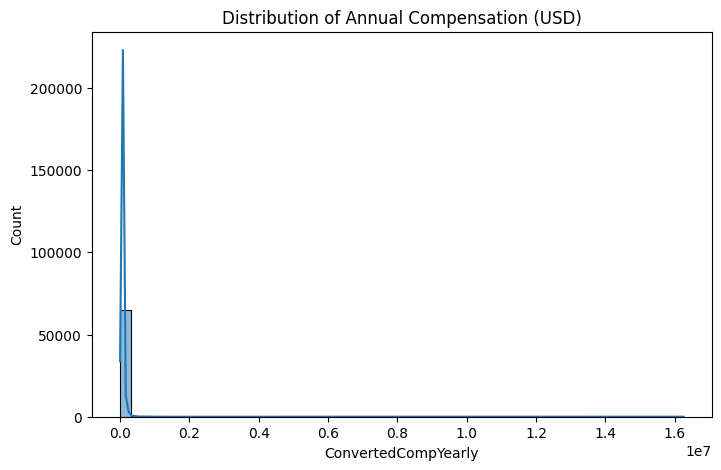

In [37]:
## Write your code here
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,5))
sns.histplot(df['ConvertedCompYearly'], bins=50, kde=True)
plt.title("Distribution of Annual Compensation (USD)")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Count")
plt.show()

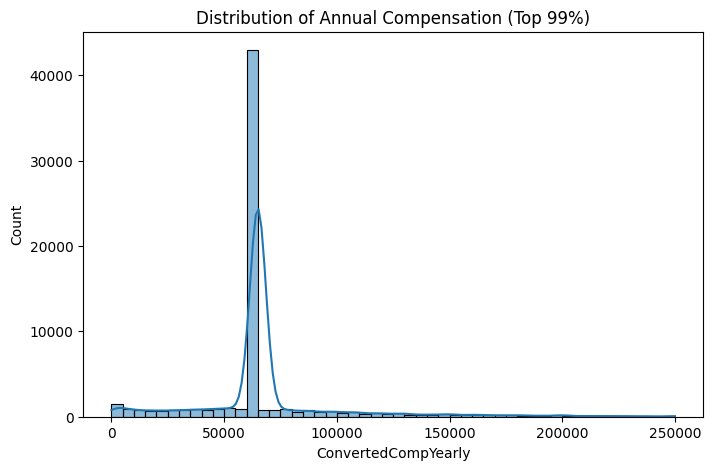

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

# Filter out top 1% to reduce skew
upper_limit = df['ConvertedCompYearly'].quantile(0.99)
filtered_df = df[df['ConvertedCompYearly'] <= upper_limit]

plt.figure(figsize=(8,5))
sns.histplot(filtered_df['ConvertedCompYearly'], bins=50, kde=True)
plt.title("Distribution of Annual Compensation (Top 99%)")
plt.xlabel("ConvertedCompYearly")
plt.ylabel("Count")
plt.show()

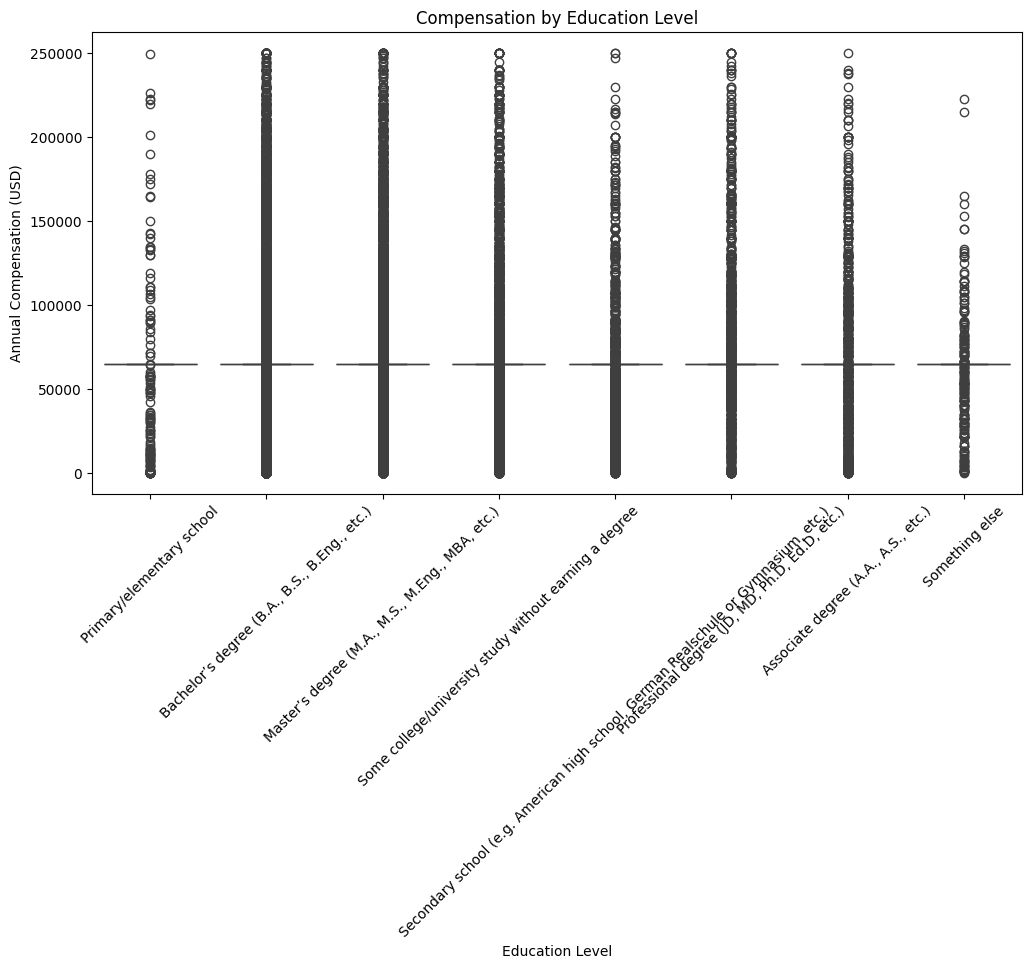

In [40]:
plt.figure(figsize=(12,6))
sns.boxplot(x='EdLevel', y='ConvertedCompYearly', data=filtered_df)
plt.xticks(rotation=45)
plt.title("Compensation by Education Level")
plt.ylabel("Annual Compensation (USD)")
plt.xlabel("Education Level")
plt.show()

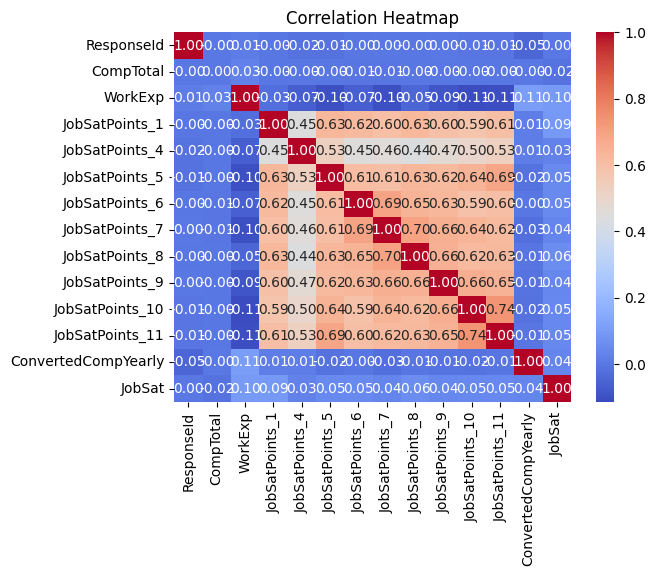

In [41]:
numeric_cols = df.select_dtypes(include=['float64', 'int64'])
corr = numeric_cols.corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
!pip install folium
!pip install pycountry
!pip install geopy

import folium
import pandas as pd
import pycountry

# Example: Convert country names to lat/lon
import geopy
from geopy.geocoders import Nominatim
geolocator = Nominatim(user_agent="geoapiExercises")

def get_coords(country_name):
    try:
        location = geolocator.geocode(country_name)
        return (location.latitude, location.longitude)
    except:
        return (None, None)

# Aggregate average compensation by country
country_avg = df.groupby('Country')['ConvertedCompYearly'].mean().reset_index()
country_avg[['lat','lon']] = country_avg['Country'].apply(lambda x: pd.Series(get_coords(x)))

# Create map
m = folium.Map(location=[20,0], zoom_start=2)
for idx, row in country_avg.iterrows():
    if pd.notnull(row['lat']):
        folium.CircleMarker(
            location=[row['lat'], row['lon']],
            radius=5,
            popup=f"{row['Country']}: ${row['ConvertedCompYearly']:,.0f}",
            color='blue',
            fill=True,
            fill_opacity=0.6
        ).add_to(m)

m

In [42]:
categorical_cols = df.select_dtypes(include=['object'])
for col in categorical_cols:
    print(df[col].value_counts().head(10))
    print("\n")

MainBranch
I am a developer by profession                                                           50207
I am not primarily a developer, but I write code sometimes as part of my work/studies     6511
I am learning to code                                                                     3875
I code primarily as a hobby                                                               3334
I used to be a developer by profession, but no longer am                                  1510
Name: count, dtype: int64


Age
25-34 years old       23911
35-44 years old       14942
18-24 years old       14098
45-54 years old        6249
55-64 years old        2575
Under 18 years old     2568
65 years or older       772
Prefer not to say       322
Name: count, dtype: int64


Employment
Employed, full-time                                                         39041
Independent contractor, freelancer, or self-employed                         4846
Student, full-time                                     

<!--
## Change Log

|Date (YYYY-MM-DD)|Version|Changed By|Change Description|
|-|-|-|-|
|2024-11-05|1.2|Madhusudhan Moole|Updated lab|
|2024-09-24|1.1|Madhusudhan Moole|Updated lab|
|2024-09-23|1.0|Raghul Ramesh|Created lab|

--!>


Copyright © IBM Corporation. All rights reserved.
